**EUROVISION SONG SUCCESS CALCULATOR - DATA SCIENCE EXIT TEST**

# **1.   DATA CLEANING AND PREPARATION**



# *TASK* *1*

**Importing Required Libraries**

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_style("whitegrid")

**Loading Dataset**

In [16]:
from google.colab import files
uploaded = files.upload()

Saving dataset.xlsx to dataset (1).xlsx


In [25]:
# Load the Eurovision metadata sheet

filename = list(uploaded.keys())[0]

df = pd.read_excel(filename, sheet_name="eurovision_meta")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (648, 30)


In [26]:
# Display the first five rows
df.head()

,Unnamed: 0,Year,Country,Region,Artist,Song,Artist.gender,Group.Solo,Place,Points,...,danceability,tempo,speechiness,key,liveness,time_signature,mode,loudness,valence,Happiness
0,1,2009,Lithuania,Former Socialist Bloc,Sasha Son,Love,Male,Solo,23,23,...,0.598360,102.984,0.027817,9.0,0.078643,3.0,0.0,-9.082,0.482059,6.148232
1,2,2009,Israel,Independent,Noa and Mira Awad,There Must Be Another Way,Female,Group,16,53,...,0.604542,105.972,0.024996,8.0,0.084805,4.0,1.0,-6.059,0.426209,5.141887
2,3,2009,France,Western Europe,Patricia Kaas,Et s'il fallait le faire,Female,Solo,8,107,...,0.367344,124.005,0.043751,1.0,0.923905,4.0,1.0,-8.655,0.292870,5.069762
3,4,2009,Sweden,Scandinavia,Malena Ernman,La voix,Female,Solo,21,33,...,0.513202,128.021,0.034855,10.0,0.143708,4.0,1.0,-4.536,0.206493,5.502692
4,5,2009,Croatia,Former Yugoslavia,Igor Cukrov feat. Andrea,Lijepa Tena,Both,Group,18,45,...,0.590592,116.107,0.032406,1.0,0.079322,4.0,0.0,-4.427,0.344541,NaN


In [27]:
# Display last five rows
df.tail()

,Unnamed: 0,Year,Country,Region,Artist,Song,Artist.gender,Group.Solo,Place,Points,...,danceability,tempo,speechiness,key,liveness,time_signature,mode,loudness,valence,Happiness
643,644,2010,Slovenia,Former Yugoslavia,Ansambel _lindra¾and¾Kalamari,Narodnozabavni rock,NaN,NaN,16,6,...,0.657474,129.953,0.042575,9.0,0.063622,4.0,1.0,-3.223,0.687482,NaN
644,645,2010,Sweden,Scandinavia,Anna Bergendahl,This Is My Life,NaN,NaN,11,62,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
645,646,2010,Switzerland,Western Europe,Michael von der Heide,Il pleut de l'or,NaN,NaN,17,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
646,647,2010,Turkey,Independent,maNga,We Could Be the Same,NaN,NaN,1,118,...,0.660555,133.032,0.044043,2.0,0.033176,4.0,0.0,-4.891,0.565634,5.599667
647,648,2010,Ukraine,Former Socialist Bloc,Alyosha,Sweet People,NaN,NaN,7,77,...,0.661755,119.954,0.037064,0.0,0.176192,4.0,1.0,-6.866,0.208532,5.603956


In [28]:
# Checking Columns
print("Columns in the dataset:")
print(df.columns.tolist())

Columns in the dataset:
['Unnamed: 0', 'Year', 'Country', 'Region', 'Artist', 'Song', 'Artist.gender', 'Group.Solo', 'Place', 'Points', 'Home.Away.Country', 'Home.Away.Region', 'Is.Final', 'Semi.Final.Number', 'Song.In.English', 'Song.Quality', 'Normalized.Points', 'energy', 'duration', 'acousticness', 'danceability', 'tempo', 'speechiness', 'key', 'liveness', 'time_signature', 'mode', 'loudness', 'valence', 'Happiness']


In [29]:
# Check Datatypes and structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 648 entries, 0 to 647
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         648 non-null    int64  
 1   Year               648 non-null    int64  
 2   Country            648 non-null    object 
 3   Region             648 non-null    object 
 4   Artist             648 non-null    object 
 5   Song               648 non-null    object 
 6   Artist.gender      226 non-null    object 
 7   Group.Solo         226 non-null    object 
 8   Place              648 non-null    int64  
 9   Points             648 non-null    int64  
 10  Home.Away.Country  648 non-null    object 
 11  Home.Away.Region   648 non-null    object 
 12  Is.Final           648 non-null    int64  
 13  Semi.Final.Number  281 non-null    float64
 14  Song.In.English    648 non-null    int64  
 15  Song.Quality       648 non-null    float64
 16  Normalized.Points  648 non

In [30]:
# Checking Missing Values
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
Unnamed: 0             0
Year                   0
Country                0
Region                 0
Artist                 0
Song                   0
Artist.gender        422
Group.Solo           422
Place                  0
Points                 0
Home.Away.Country      0
Home.Away.Region       0
Is.Final               0
Semi.Final.Number    367
Song.In.English        0
Song.Quality           0
Normalized.Points      0
energy               166
duration             166
acousticness         168
danceability         166
tempo                166
speechiness          166
key                  166
liveness             166
time_signature       166
mode                 166
loudness             166
valence              168
Happiness            344
dtype: int64


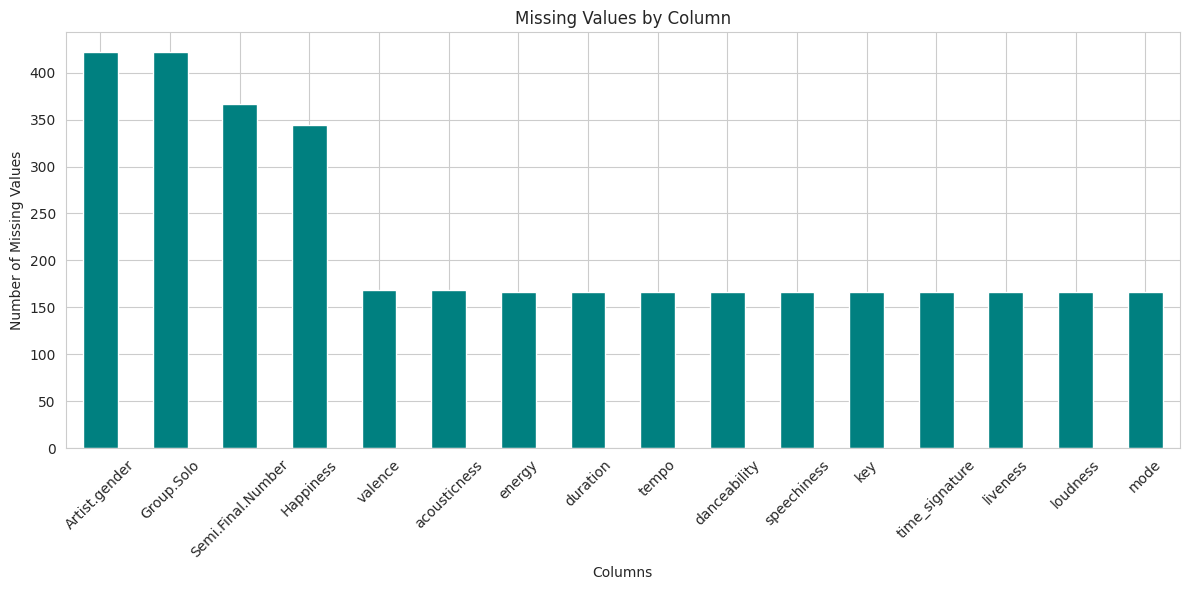

In [33]:
plt.figure(figsize=(12, 6))

missing_values[missing_values > 0].sort_values(ascending=False).plot(
    kind="bar",
    color= "teal"
)

plt.title("Missing Values by Column")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [35]:
# Checking Duplicates
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [36]:
# Remove unnecessary index column
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

print("Shape after removing unnecessary index column:", df.shape)

Shape after removing unnecessary index column: (648, 29)


In [37]:
# Missing Value Handling
missing = df.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

print(missing)

Artist.gender        422
Group.Solo           422
Semi.Final.Number    367
Happiness            344
valence              168
acousticness         168
energy               166
duration             166
tempo                166
danceability         166
speechiness          166
key                  166
time_signature       166
liveness             166
loudness             166
mode                 166
dtype: int64


In [39]:
numeric_columns = df.select_dtypes(include=np.number).columns

for column in numeric_columns:
    if df[column].isnull().sum() > 0:
        df[column] = df[column].fillna(df[column].median())

In [41]:
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    if df[column].isnull().sum() > 0:
        df[column] = df[column].fillna(df[column].mode()[0])

### Justification for Handling Missing Values

Missing values were handled according to the type of variable.

- **Numerical columns:** Missing numerical values were replaced using the **median** of the respective column. Median imputation was chosen because it is less affected by extreme values and outliers than the mean. This is suitable for numerical song/audio features such as 'danceability', 'energy', and 'tempo'.

- **Categorical columns:** Missing categorical values were replaced using the **mode (most frequent value)** of the respective column. This preserves the categorical nature of variables such as 'Artist.gender' and 'Group.Solo' and avoids unnecessarily removing observations.

This approach allows us to retain as much data as possible while using reasonable values based on the existing data distribution.

In [42]:
print("Final Dataset Shape:", df.shape)

print("\nRemaining Missing Values:")
print(df.isnull().sum().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Final Dataset Shape: (648, 29)

Remaining Missing Values:
0

Duplicate Rows:
0


In [43]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Year,648.0,NaN,NaN,NaN,2006.54321,4.016733,1998.0,2004.0,2007.0,2010.0,2012.0
Country,648,48,Turkey,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Region,648,5,Former Socialist Bloc,213,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Artist,648,530,Jedward,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Song,648,509,Angel,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Artist.gender,648,3,Female,523,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Group.Solo,648,2,Solo,575,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Place,648.0,NaN,NaN,NaN,11.858025,6.795186,1.0,6.0,12.0,17.0,28.0
Points,648.0,NaN,NaN,NaN,77.783951,63.301464,0.0,30.0,62.0,110.0,387.0
Home.Away.Country,648,2,Away,634,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# *TASK 2 and TASK 3*

*   1. Count of artists by gender




/tmp/ipykernel_1140/680408913.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


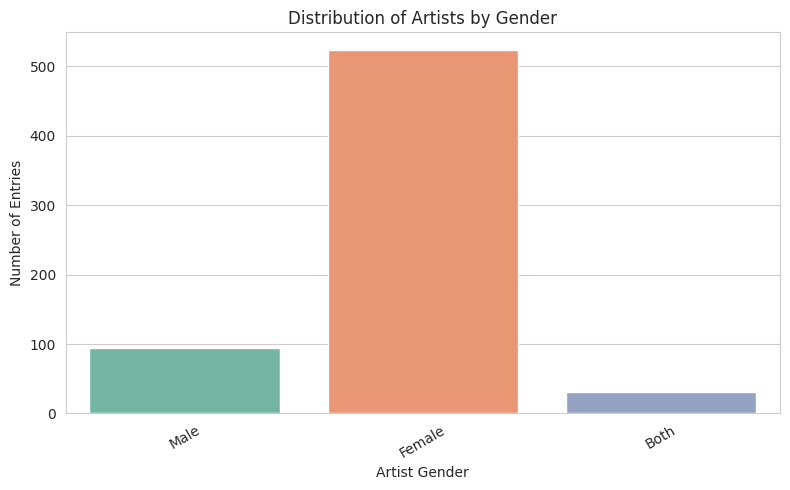

In [46]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Artist.gender",
    palette="Set2"
)

plt.title("Distribution of Artists by Gender")
plt.xlabel("Artist Gender")
plt.ylabel("Number of Entries")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

* 2. Gender vs Eurovision Points

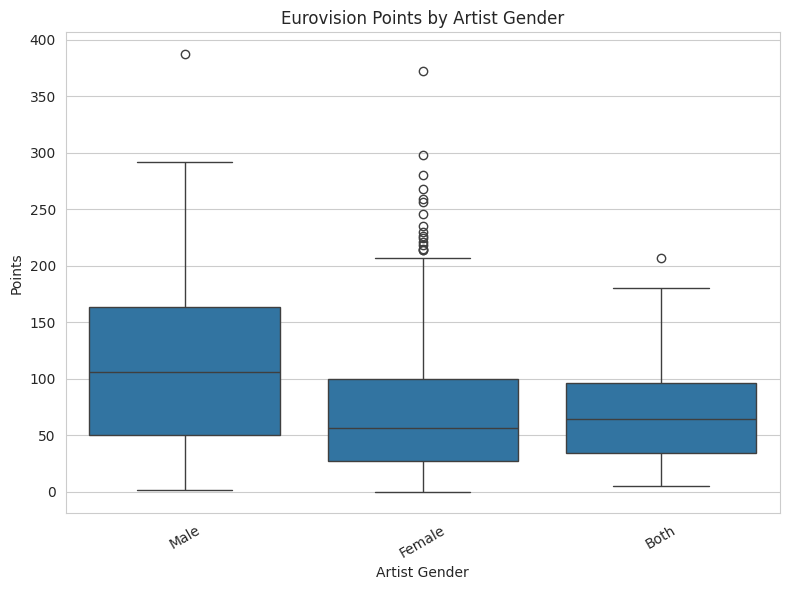

In [47]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="Artist.gender",
    y="Points"
)

plt.title("Eurovision Points by Artist Gender")
plt.xlabel("Artist Gender")
plt.ylabel("Points")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

* 3. Mean Points by gender

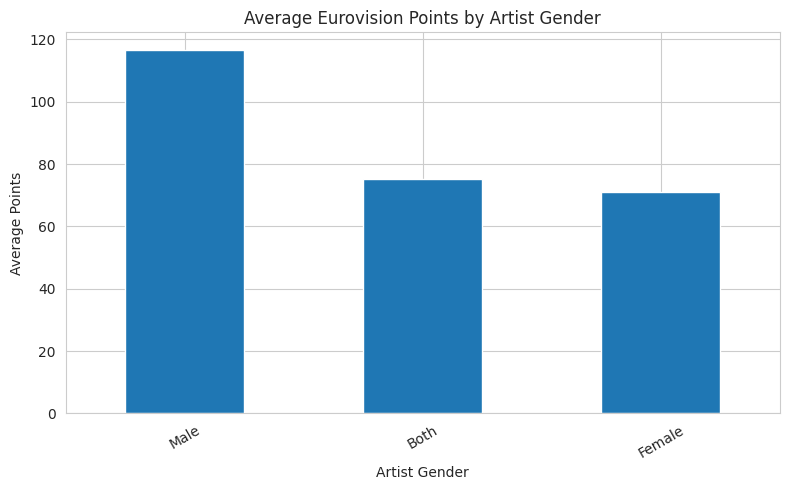

In [48]:
gender_points = (
    df.groupby("Artist.gender")["Points"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

gender_points.plot(kind="bar")

plt.title("Average Eurovision Points by Artist Gender")
plt.xlabel("Artist Gender")
plt.ylabel("Average Points")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [49]:
# Nmerical Comparison
print("Average Points by Artist Gender:")
print(gender_points)

Average Points by Artist Gender:
Artist.gender
Male      116.404255
Both       75.096774
Female     71.001912
Name: Points, dtype: float64


### Observation – Artist Gender vs Points

The distribution of Eurovision points varies across the different artist
gender categories. The boxplot shows differences in the central tendency
and spread of points between categories.

The average-points comparison provides a clearer numerical comparison of
the groups. However, differences in the number of observations between
gender categories should also be considered when interpreting the results.

Therefore, Artist.gender may have some association with Eurovision points,
but it should not be interpreted as a direct cause of higher or lower scores.

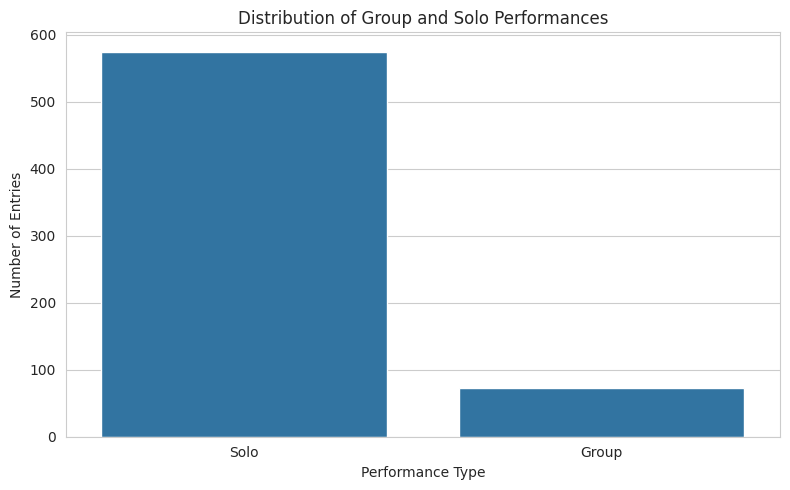

In [51]:
# Countplot
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Group.Solo"
)

plt.title("Distribution of Group and Solo Performances")
plt.xlabel("Performance Type")
plt.ylabel("Number of Entries")

plt.tight_layout()
plt.show()

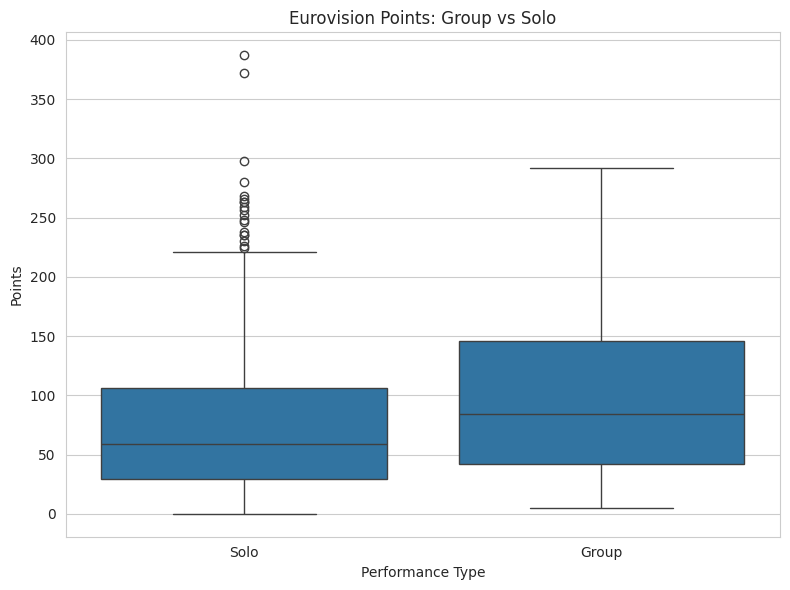

In [53]:
# Boxplot
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="Group.Solo",
    y="Points"
)

plt.title("Eurovision Points: Group vs Solo")
plt.xlabel("Performance Type")
plt.ylabel("Points")

plt.tight_layout()
plt.show()

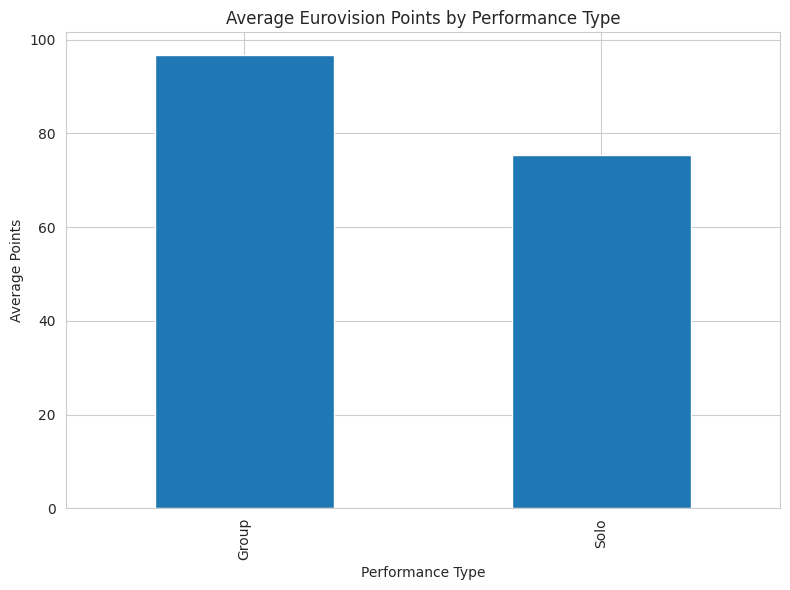

In [54]:
# Average Points
group_points = (
    df.groupby("Group.Solo")["Points"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,6))

group_points.plot(kind="bar")

plt.title("Average Eurovision Points by Performance Type")
plt.xlabel("Performance Type")
plt.ylabel("Average Points")

plt.tight_layout()
plt.show()

### Observation – Group/Solo vs Points

The boxplot compares the distribution of Eurovision points for group and solo performances. The average-points chart provides a numerical comparison between the two categories.
The results indicate whether one performance type tends to receive higher points on average.However, the difference should be interpreted together with the number of observations in each category rather than assuming that performance type alone determines Eurovision success.

In [57]:
# Feature and Target
target = "Points"

In [58]:
print(df.columns.tolist())

['Year', 'Country', 'Region', 'Artist', 'Song', 'Artist.gender', 'Group.Solo', 'Place', 'Points', 'Home.Away.Country', 'Home.Away.Region', 'Is.Final', 'Semi.Final.Number', 'Song.In.English', 'Song.Quality', 'Normalized.Points', 'energy', 'duration', 'acousticness', 'danceability', 'tempo', 'speechiness', 'key', 'liveness', 'time_signature', 'mode', 'loudness', 'valence', 'Happiness']


In [60]:
features = [
    "Year",
    "Artist.gender",
    "Group.Solo",
    "Song.In.English",
    "energy",
    "duration",
    "acousticness",
    "danceability",
    "tempo",
    "speechiness",
    "key",
    "liveness",
    "time_signature",
    "mode",
    "loudness",
    "valence",
    "Happiness"
]

In [63]:
# Creating X and Y

X = df[features]
y = df[target]

print("Features shape:" , X.shape)
print("Target shape:", y.shape)

Features shape: (648, 17)
Target shape: (648,)


In [64]:
display(X.head())

,Year,Artist.gender,Group.Solo,Song.In.English,energy,duration,acousticness,danceability,tempo,speechiness,key,liveness,time_signature,mode,loudness,valence,Happiness
0,2009,Male,Solo,1,0.678258,183.18476,0.563170,0.598360,102.984,0.027817,9.0,0.078643,3.0,0.0,-9.082,0.482059,6.148232
1,2009,Female,Group,1,0.794093,179.87873,0.068711,0.604542,105.972,0.024996,8.0,0.084805,4.0,1.0,-6.059,0.426209,5.141887
2,2009,Female,Solo,0,0.574628,227.97333,0.654078,0.367344,124.005,0.043751,1.0,0.923905,4.0,1.0,-8.655,0.292870,5.069762
3,2009,Female,Solo,1,0.672746,178.45660,0.119194,0.513202,128.021,0.034855,10.0,0.143708,4.0,1.0,-4.536,0.206493,5.502692
4,2009,Both,Group,0,0.733959,182.83057,0.323643,0.590592,116.107,0.032406,1.0,0.079322,4.0,0.0,-4.427,0.344541,5.464790


In [65]:
display(y.head())

,Points
0,23
1,53
2,107
3,33
4,45


### Feature and Target Selection

The target variable selected for the regression task is 'Points', because the
objective is to predict the number of Eurovision points received by a song.

The selected features include artist characteristics, performance type,
whether the song is in English, and measurable audio characteristics such as
energy, duration, acousticness, danceability, tempo, speechiness, liveness,
loudness, valence and Happiness.

These variables were selected because they provide information about the song,
artist and musical characteristics that may be associated with Eurovision
points.

# **2.EDA AND MODELLING**


##  *TASK* *4*



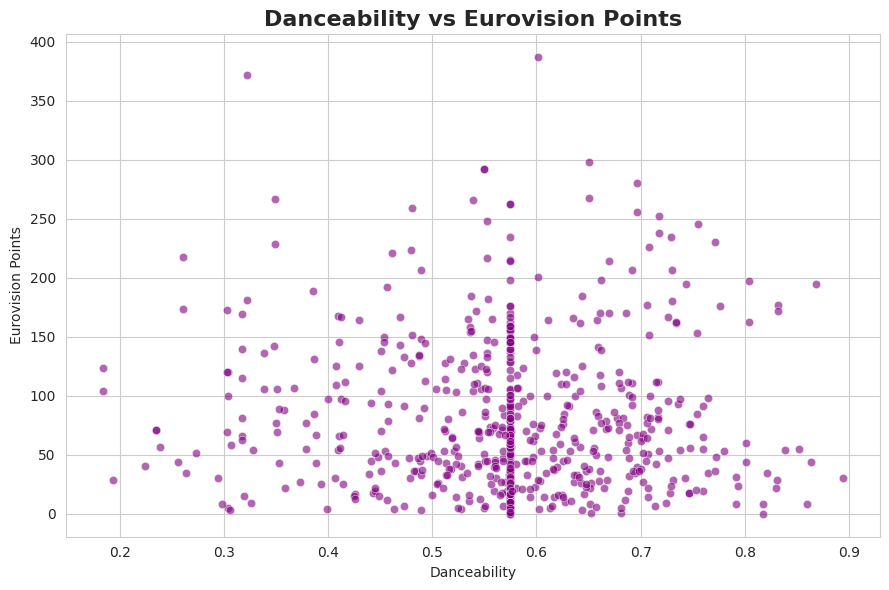

In [66]:
# SCATTER PLOT

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="danceability",
    y="Points",
    color="purple",
    alpha=0.6
)

plt.title(
    "Danceability vs Eurovision Points",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Danceability")
plt.ylabel("Eurovision Points")

plt.tight_layout()
plt.show()

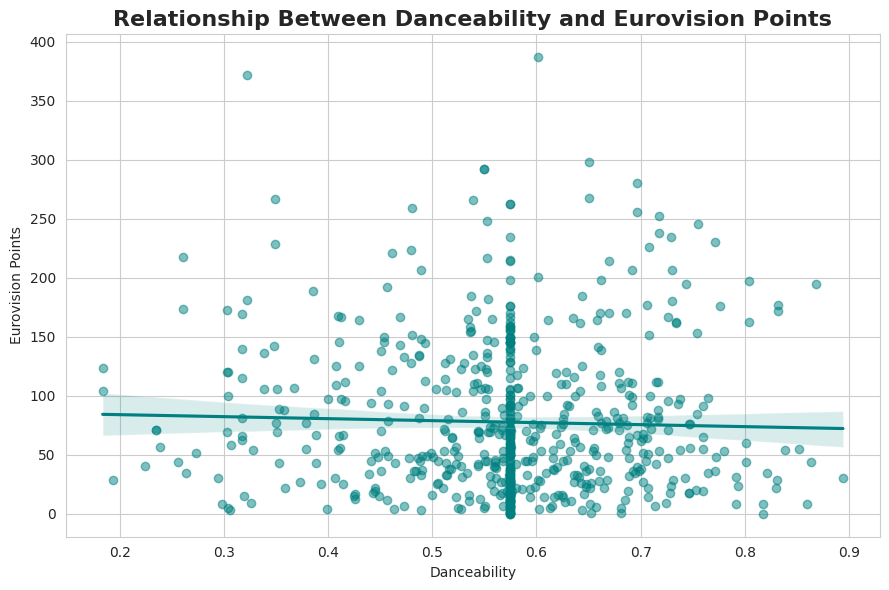

In [69]:
# Regression Trend

plt.figure(figsize=(9, 6))

sns.regplot(
    data=df,
    x="danceability",
    y="Points",
    scatter_kws={"alpha": 0.5},
    color="teal"
)

plt.title(
    "Relationship Between Danceability and Eurovision Points",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Danceability")
plt.ylabel("Eurovision Points")

plt.tight_layout()
plt.show()

In [70]:
correlation = df["danceability"].corr(df["Points"])

print("Correlation between Danceability and Points:",correlation)

Correlation between Danceability and Points: -0.03136966158376967



### Observation – Danceability vs Eurovision Points

The correlation between danceability and Eurovision Points is approximately
-0.031. This value is very close to zero, indicating a negligible negative
linear relationship between the two variables.

The scatter plot also shows that the points are widely dispersed rather than
following a clear upward or downward pattern. Therefore, higher danceability
does not appear to be strongly associated with higher Eurovision Points.

Based on this analysis, the null hypothesis that there is no meaningful
linear relationship between danceability and Eurovision Points appears more
plausible. However, Eurovision success is influenced by multiple factors, so
danceability alone cannot determine the number of points received.


# *TASK 5 - Preparing the Data for Modelling*

In [72]:
# Define categorical and numerical features
categorical_features = [
    "Artist.gender",
    "Group.Solo"
]

numerical_features = [
    feature for feature in features
    if feature not in categorical_features
]

print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

Categorical Features:
['Artist.gender', 'Group.Solo']

Numerical Features:
['Year', 'Song.In.English', 'energy', 'duration', 'acousticness', 'danceability', 'tempo', 'speechiness', 'key', 'liveness', 'time_signature', 'mode', 'loudness', 'valence', 'Happiness']


In [74]:
# Creating the preprocessing pipeline

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numerical_features),
    ("categorical", categorical_pipeline, categorical_features)
])

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


### Categorical Feature Transformation

The categorical features 'Artist.gender' and 'Group.Solo' were transformed
using One-Hot Encoding so that they could be used by the regression model.

One-Hot Encoding was selected because these categories do not have a natural
numerical order. Therefore, assigning numbers such as 0, 1 and 2 could create
a false relationship between the categories.

Missing categorical values were handled using the most frequent category,
while missing numerical values were handled using median imputation.

**Train/Test Split**

In [78]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)
print("Training Target:", y_train.shape)
print("Testing Target:",y_test.shape)

Training Features: (518, 17)
Testing Features: (130, 17)
Training Target: (518,)
Testing Target: (130,)


### Train-Test Split

The dataset was divided into 80% training data and 20% testing data.

The training data is used to train the regression model, while the testing
data is kept separate and is used to evaluate the model on unseen
observations.

A random state of 42 was used to make the results reproducible.

*TASK - 6 Gradient Boosting Regressor*

In [80]:
from sklearn.ensemble import GradientBoostingRegressor

model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

print("Gradient Boosting Regressor created successfully.")

Gradient Boosting Regressor created successfully.


In [81]:
model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [82]:
y_pred = model.predict(X_test)

print("First 10 predictions:")
print(y_pred[:10])

First 10 predictions:
[ 55.7309889   40.20363961 102.55159076  57.64566163  93.1947513
 116.22679943  39.51071907 109.44073586  40.79310451  40.20363961]


In [85]:
# Calculate MAE
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("R² Score:", r2)

Mean Absolute Error (MAE): 45.78157074278463
R² Score: 0.1159920700756496


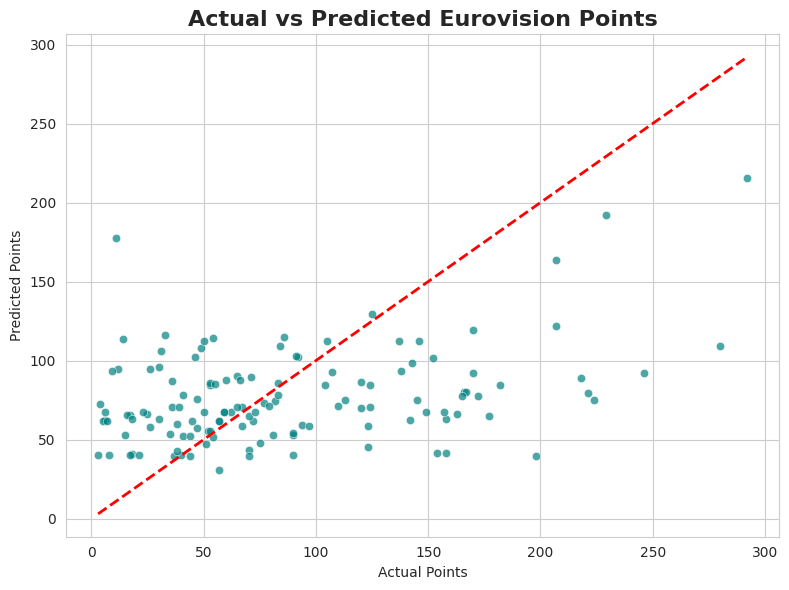

In [87]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_test,
    y=y_pred,
    color="teal",
    alpha=0.7
)

min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    color="red",
    linestyle="--",
    linewidth=2
)

plt.title(
    "Actual vs Predicted Eurovision Points",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Actual Points")
plt.ylabel("Predicted Points")

plt.tight_layout()
plt.show()

### Observation of the Scatter Plot - Actual vs Predicted Points

The Actual vs Predicted plot compares the Eurovision points observed in the
test dataset with the points predicted by the Gradient Boosting model.

The red dashed line represents perfect predictions. Points closer to this line
indicate smaller prediction errors, while points farther from the line indicate
larger errors.

The relatively dispersed points are consistent with the MAE of 45.78 and the
R² score of 0.116, suggesting that the model has limited predictive accuracy
for Eurovision Points.

### Model Evaluation - MAE

The Gradient Boosting Regressor achieved a Mean Absolute Error (MAE) of
approximately 45.78 points.

This means that, on average, the model's predicted Eurovision score differs
from the actual Eurovision score by approximately 45.78 points.

A lower MAE indicates better prediction accuracy because it means that the
predicted scores are closer to the actual scores.

The model achieved an R² score of approximately 0.116, indicating that the
selected features explain a relatively small proportion of the variation in
Eurovision Points. Therefore, Eurovision success is likely influenced by
additional factors that are not captured by the selected features.

In [90]:
# Saving the Model
import joblib

joblib.dump(model, "eurovision_success_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [89]:
# Verifying
import os

print(os.listdir())

['.config', 'dataset.xlsx', 'eurovision_success_model.pkl', 'dataset (1).xlsx', 'sample_data']


In [91]:
from google.colab import files

files.download("eurovision_success_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>